In [1]:
import os, random, numpy as np
SEED = 23
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("OMP_NUM_THREADS", "1")
random.seed(SEED)
np.random.seed(SEED)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import squidpy as sq
import os

In [ ]:
## AFTER PLAYING AROUND WITH DIFFERENT METHODS OF ANALYSIS 
## BUILD GRAPH USING SQUIDPY -> NEIGHBOURHOOD COMPOISITION FOR EACH CELLS --> CLR TRANSFORMED --> KMEANS

In [10]:
import scanpy as sc
import squidpy as sq
import pandas as pd
import numpy as np
from scipy import sparse
from sklearn.cluster import KMeans

# ---------------------------------------------------------------------
# parameters
# ---------------------------------------------------------------------
radius        = 50.0          # µm
k             = 15            # K-means clusters

# adata_list and sample_names were defined earlier --------------------
adata_list = [
    adata_065_314, adata_074_314, adata_096_314,adata_097_314,
    adata_099_314, adata_104_314, adata_106_314,adata_107_314,  
    adata_065_480, adata_074_480, adata_096_480, adata_097_480,
    adata_099_480, adata_104_480, adata_106_480, adata_107_480
]

# Corresponding sample names
sample_names = [
    "MH065_314", "MH074_314", "MH096_314", "MH097_314",
    "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
    "MH065_480", "MH074_480","MH096_480", "MH097_480",
    "MH099_480", "MH104_480", "MH106_480", "MH107_480"
]
assert len(adata_list) == len(sample_names)

In [11]:
# ---------------------------------------------------------------------
# helper to build a neighbour-fraction AnnData for ONE slide
# ---------------------------------------------------------------------
def build_neigh_anndata(ad, sample, radius=50.0):
    ad = ad.copy()
    ad.obs["sample"] = sample
    ad.obs["cell_id"] = ad.obs_names.values  # keep original id # *** 
    
    # radius graph
    sq.gr.spatial_neighbors(
        ad, coord_type="generic",
        radius=radius, #have checked that radius is in micrometer
        delaunay=False,
        key_added="spatial",
        set_diag=False #(by default to exclude self-interaction)
    )
    adj = ad.obsp["spatial_connectivities"]          # CSR (spots × spots)

    # one-hot cell-type matrix
    labels  = ad.obs["cell_type"].astype(str)
    ct_ohe  = pd.get_dummies(labels)                  # dense → convert to CSR
    ct_mat  = sparse.csr_matrix(ct_ohe.values)

    # neighbour counts → fractions
    counts   = adj @ ct_mat
    row_sum  = np.asarray(counts.sum(1)).ravel()
    
    keep     = row_sum > 0                           # drop isolated / edge
    counts   = counts[keep]
    row_sum  = row_sum[keep]
    ids_keep = ad.obs_names[keep]

    frac     = counts.multiply(1 / row_sum[:, None]) # 0–1, still CSR
    
    ad_n = sc.AnnData(
        X   = frac,
        obs = ad.obs.loc[ids_keep, ["sample","cell_id","cell_type"]].copy(), # add cell id *****
        var = pd.DataFrame(index=ct_ohe.columns )
    )
    ad_n.obsm["spatial"] = ad.obsm["spatial"][keep].copy()
    ad_n.uns["spatial_params"] = {"radius": radius} ## ***
    ad_n.obs_names = ids_keep
    return ad_n

In [12]:
# ---------------------------------------------------------------------
# 1. build neighbour AnnDatas for all slides
# ---------------------------------------------------------------------
neigh_list = [build_neigh_anndata(ad, name, radius) for ad, name in zip(adata_list, sample_names)] # version 3

# ---------------------------------------------------------------------
# 2. concatenate -> one matrix (cells × cell-types)
# ---------------------------------------------------------------------
combined = sc.concat(
    neigh_list,
    join           = "outer",    # union of cell-types
    label          = "sample",   # sample ID preserved
    keys           = sample_names,
    fill_value     = 0.0,
    index_unique   = "-", #to ensure each cell label is unique
    merge          = "first"     # keep unique .uns entries
)

# Freeze row and column order 
combined = combined[combined.obs_names.sort_values(), :].copy()
combined = combined[:, sorted(list(combined.var_names))].copy()

In [13]:
# ---------------------------------------------------------------------
# 3. CLR TRANSFORMATION 
# ---------------------------------------------------------------------
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy import sparse

pseudocount = 1e-3

X = combined.X.toarray() if sparse.issparse(combined.X) else np.asarray(combined.X)
X = X.astype(np.float32)

# CLR transform
X += pseudocount
geom_mean = np.exp(np.mean(np.log(X), axis=1, keepdims=True))
X_clr = np.log(X / geom_mean)

# center + scale
scaler = StandardScaler(with_mean=True, with_std=True)
X_std = scaler.fit_transform(X_clr)

In [14]:
combined.obsm['X_std'] = X_std.astype(np.float32)

In [1]:
# ---------------------------------------------------------------------
# DECIDING ON K values
# ---------------------------------------------------------------------
# ---- K selection for 3M cells: elbow + stability + held-out ----
import numpy as np
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics.pairwise import cosine_similarity
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

# ---------- helpers ----------
def rng_choice(n, size, rng, replace=False):
    size = min(size, n)
    return rng.choice(n, size=size, replace=replace)

def knee_point(pts):
    # pts: (K, y) with K increasing
    K = pts[:, 0].astype(float)
    y = pts[:, 1].astype(float)
    x1, y1, x2, y2 = K[0], y[0], K[-1], y[-1]
    den = np.hypot(x2 - x1, y2 - y1)
    d = np.abs((y2 - y1) * K - (x2 - x1) * y + x2 * y1 - y2 * x1) / den
    return int(K[np.argmax(d)])

def minibatch_fit_stream(X, K, batch_size=8192, epochs=2, seed=0, n_init=3, sample_weight=None):
    """Stream data in mini-batches using partial_fit (memory safe)."""
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    km = MiniBatchKMeans(n_clusters=K, random_state=seed, n_init=n_init, batch_size=batch_size)
    # Initialize with a small random subset for robust starts
    init_idx = rng_choice(n, min(10000, n), rng)
    km.partial_fit(X[init_idx], sample_weight=None if sample_weight is None else sample_weight[init_idx])
    # Epochs over the whole dataset
    for _ in range(epochs):
        order = rng.permutation(n)
        for start in range(0, n, batch_size):
            sl = order[start:start + batch_size]
            km.partial_fit(X[sl], sample_weight=None if sample_weight is None else sample_weight[sl])
    return km

def per_point_inertia(km, X_eval):
    # sklearn's score returns negative SSE; divide by N to get mean SSE per point
    return -km.score(X_eval) / len(X_eval)

def centroid_stability(X, K, n_sub=100_000, seed=0, batch_size=8192):
    rng = np.random.RandomState(seed)
    idx1 = rng_choice(X.shape[0], n_sub, rng)
    idx2 = rng_choice(X.shape[0], n_sub, rng)
    km1 = MiniBatchKMeans(K, random_state=seed, n_init=3, batch_size=batch_size).fit(X[idx1])
    km2 = MiniBatchKMeans(K, random_state=seed + 1, n_init=3, batch_size=batch_size).fit(X[idx2])
    S = cosine_similarity(km1.cluster_centers_, km2.cluster_centers_)
    r, c = linear_sum_assignment(-S)  # maximize total similarity
    return float(S[r, c].mean())

def heldout_error(X_train, X_val, K, seed=0, batch_size=8192):
    km = MiniBatchKMeans(K, random_state=seed, n_init=3, batch_size=batch_size).fit(X_train)
    return per_point_inertia(km, X_val)

# ---------- main driver ----------
def evaluate_K_range(
    X,
    Ks=range(6, 31),
    seed=0,
    batch_size=8192,
    epochs=2,
    eval_size=200_000,
    stability_sub=100_000,
    heldout_train=500_000,
    heldout_val=500_000,
    sample_weight=None
):
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    eval_idx = rng_choice(n, eval_size, rng)
    X_eval = X[eval_idx]

    # held-out splits
    tr_idx = rng_choice(n, heldout_train, rng, replace=False)
    va_pool = np.setdiff1d(np.arange(n), tr_idx, assume_unique=False)
    va_idx = rng_choice(len(va_pool), heldout_val, rng, replace=False)
    X_tr, X_va = X[tr_idx], X[va_pool[va_idx]]

    inertias = []
    stabilities = []
    val_errors = []

    for K in Ks:
        # streamed fit for elbow
        km = minibatch_fit_stream(
            X, K, batch_size=batch_size, epochs=epochs, seed=seed, n_init=3,
            sample_weight=sample_weight
        )
        inertias.append(per_point_inertia(km, X_eval))
        # centroid stability on split halves
        stabilities.append(centroid_stability(X, K, n_sub=stability_sub, seed=seed, batch_size=batch_size))
        # held-out recon error
        val_errors.append(heldout_error(X_tr, X_va, K, seed=seed, batch_size=batch_size))
        print(f"K={K:2d}  inertia={inertias[-1]:.4f}  stability={stabilities[-1]:.4f}  heldout={val_errors[-1]:.4f}")

    Ks = np.array(list(Ks))
    inertias = np.array(inertias)
    stabilities = np.array(stabilities)
    val_errors = np.array(val_errors)

    # knee from inertia + from heldout
    elbow_pts = np.column_stack([Ks, inertias])
    heldout_pts = np.column_stack([Ks, val_errors])
    k_elbow = knee_point(elbow_pts)
    k_val_knee = knee_point(heldout_pts)

    # plotting
    fig, axs = plt.subplots(3, 1, figsize=(7, 12))
    axs[0].plot(Ks, inertias, marker='o')
    axs[0].axvline(k_elbow, linestyle='--')
    axs[0].set_title("Elbow: mean SSE per point vs K")
    axs[0].set_xlabel("K"); axs[0].set_ylabel("Mean SSE")

    axs[1].plot(Ks, stabilities, marker='o')
    axs[1].set_title("Centroid stability (mean cosine similarity)")
    axs[1].set_xlabel("K"); axs[1].set_ylabel("Stability")

    axs[2].plot(Ks, val_errors, marker='o')
    axs[2].axvline(k_val_knee, linestyle='--')
    axs[2].set_title("Held-out reconstruction error vs K")
    axs[2].set_xlabel("K"); axs[2].set_ylabel("Mean SSE (held-out)")

    plt.tight_layout()
    return {
        "Ks": Ks,
        "inertia": inertias,
        "stability": stabilities,
        "heldout": val_errors,
        "knee_inertia": k_elbow,
        "knee_heldout": k_val_knee,
    }

In [6]:
combined = sc.read_h5ad('Combined_CLR_transform_global_CN_Aug14.h5ad')

sec = combined.obs["sample"].to_numpy()
sec_counts = pd.Series(sec).value_counts()
w = 1.0 / sec_counts[sec].to_numpy()

K= 8  inertia=31.0869  stability=0.6649  heldout=31.2066
K= 9  inertia=30.5577  stability=0.7748  heldout=30.4935
K=10  inertia=30.0134  stability=0.7193  heldout=30.1310
K=11  inertia=29.6453  stability=0.7466  heldout=29.5925
K=12  inertia=29.4390  stability=0.7488  heldout=29.4116
K=13  inertia=28.9623  stability=0.7992  heldout=28.8668
K=14  inertia=28.5841  stability=0.7421  heldout=28.1257
K=15  inertia=28.1351  stability=0.7592  heldout=27.7917
K=16  inertia=27.8763  stability=0.7650  heldout=27.4583
K=17  inertia=27.7305  stability=0.7702  heldout=27.0985
K=18  inertia=27.5455  stability=0.8547  heldout=26.8647
K=19  inertia=27.3180  stability=0.7707  heldout=27.0275
K=20  inertia=26.9282  stability=0.7301  heldout=26.7762
K=21  inertia=26.2068  stability=0.7419  heldout=26.4398
K=22  inertia=26.0028  stability=0.7369  heldout=25.5448
K=23  inertia=25.6790  stability=0.7687  heldout=25.7815
K=24  inertia=25.5435  stability=0.7691  heldout=25.3826
K=25  inertia=25.3759  stabilit

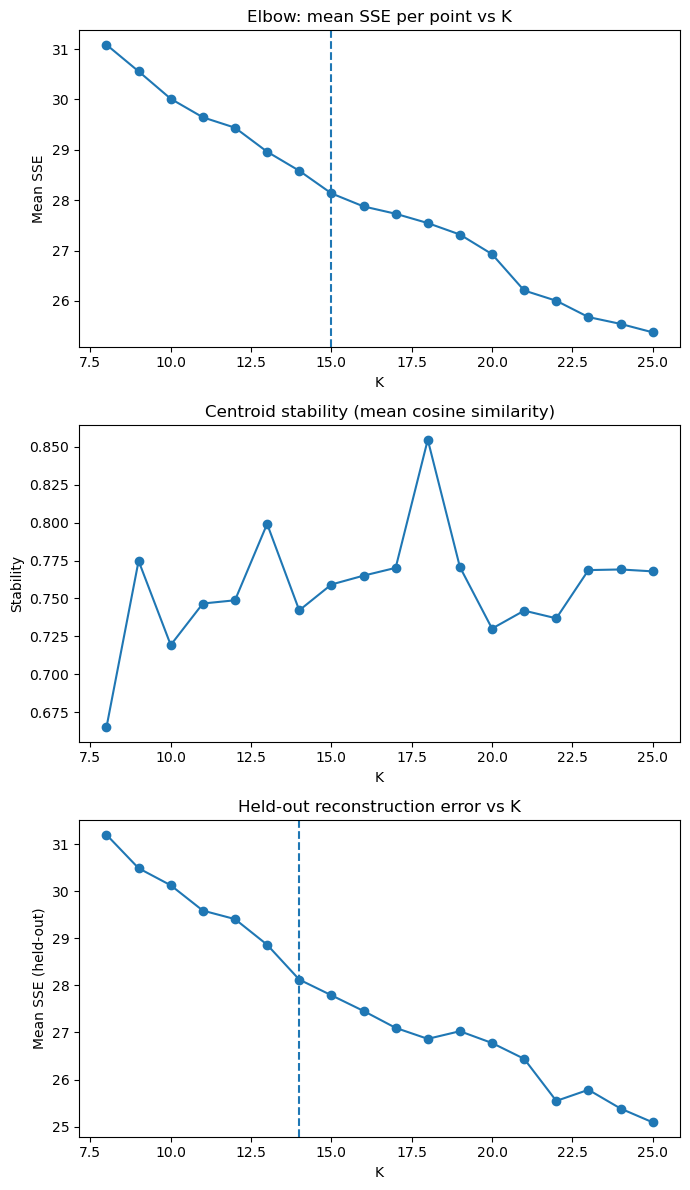

In [10]:
results = evaluate_K_range(
    X_std,
    Ks=range(8, 26),
    seed=42,
    sample_weight=w        
)

km, labels = final_refit_and_labels(
    X_std,
    K=15,
    w=w,                  
    seed=42,
    use_full_kmeans=False  # set True if you want exact KMeans at the end
)

In [15]:
# ---------------------------------------------------------------------
# 4. FIT KMEANS with WEIGHTS
# ---------------------------------------------------------------------
sec = combined.obs["sample"].to_numpy()
sec_counts = pd.Series(sec).value_counts()
w = 1.0 / sec_counts[sec].to_numpy()

km = KMeans(n_clusters=k, 
            random_state=SEED, n_init=12,
            algorithm="lloyd", #default
            max_iter=300, #default
            tol=1e-4 #default
           ).fit(X_std, sample_weight=w)
combined.obs["niche_CLR_km"] = km.labels_.astype(str)

In [16]:
import pandas as pd

# Build label map with a key
lbl = combined.obs[["sample", "cell_id", "niche_CLR_km"]].copy()

# check duplicates
dup_src = lbl.duplicated(["sample","cell_id"]).sum()
assert dup_src == 0, f"combined has {dup_src} duplicate (sample,cell_id) rows"

label_map = lbl.set_index(["sample","cell_id"])["niche_CLR_km"]

summary = []
for ad in neigh_list:
    # check for duplicates in target
    dup_tgt = ad.obs.duplicated(["sample","cell_id"]).sum()
    assert dup_tgt == 0, f"{ad.obs['sample'].iat[0]} has {dup_tgt} duplicate (sample,cell_id)"

    keys = pd.MultiIndex.from_frame(ad.obs[["sample","cell_id"]])
    mapped = label_map.reindex(keys)

    n_na = int(mapped.isna().sum())
    summary.append({
        "sample": ad.obs["sample"].iat[0],
        "n_total": ad.n_obs,
        "n_unmapped": n_na,
        "pct_unmapped": 100*n_na/ad.n_obs
    })

    # policy: fail loudly OR keep as 'unmapped'
    assert n_na == 0, f"{ad.obs['sample'].iat[0]} has {n_na} unmapped cells"
    # ad.obs["niche_CLR_km"] = mapped.fillna("unmapped").astype(str)  # <- use this line instead if you prefer labeling

# quick report
summary = pd.DataFrame(summary).sort_values("pct_unmapped", ascending=False)
print(summary)

       sample  n_total  n_unmapped  pct_unmapped
0   MH065_314   154176           0           0.0
1   MH074_314   145705           0           0.0
2   MH096_314   174716           0           0.0
3   MH097_314   282221           0           0.0
4   MH099_314   141533           0           0.0
5   MH104_314   101803           0           0.0
6   MH106_314   153258           0           0.0
7   MH107_314    97628           0           0.0
8   MH065_480    93868           0           0.0
9   MH074_480   264515           0           0.0
10  MH096_480   458935           0           0.0
11  MH097_480   194614           0           0.0
12  MH099_480   144203           0           0.0
13  MH104_480   162776           0           0.0
14  MH106_480   146095           0           0.0
15  MH107_480   214195           0           0.0


In [19]:
# 1) Use ORIGINAL fractions (no pseudocount)
X_frac = combined.X.A if sparse.issparse(combined.X) else np.asarray(combined.X)
dfX = pd.DataFrame(X_frac, index=combined.obs_names, columns=combined.var_names)

# 2) Niche means (fractions are easy to interpret)
niche_means = (
    dfX.join(combined.obs["niche_CLR_km"])
       .groupby("niche_CLR_km")
       .mean()
       .sort_index()
)

Text(158.22222222222223, 0.5, 'K-means niche_version3_CLR')

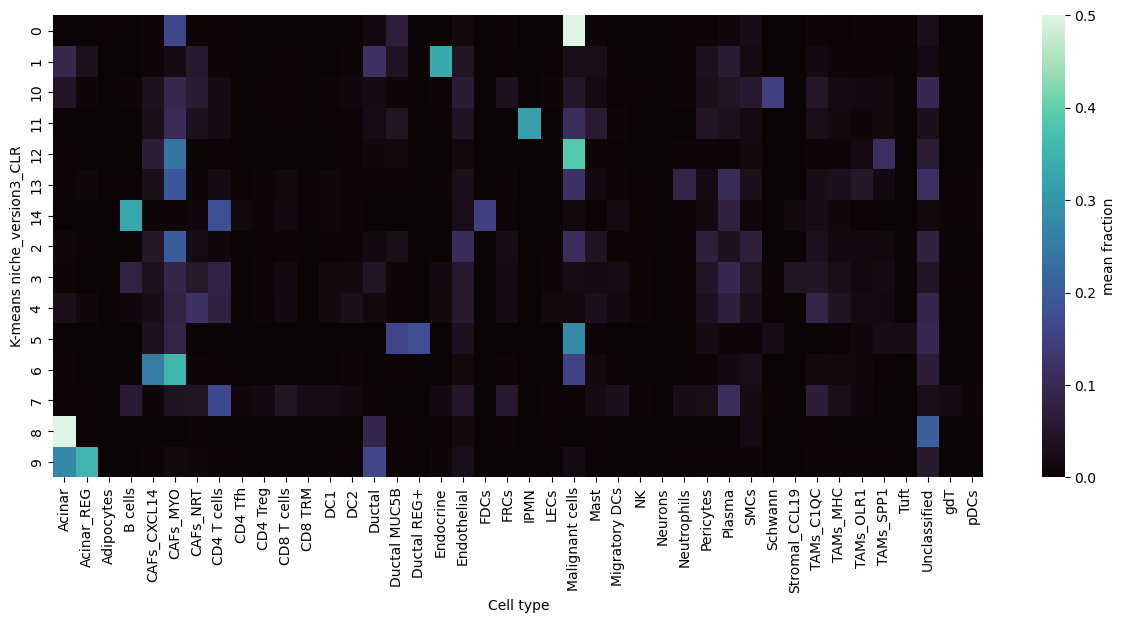

In [20]:
plt.figure(figsize=(15, 6))
sns.heatmap(niche_means, cmap="mako", vmax=0.5, cbar_kws={"label": "mean fraction"})
plt.xlabel("Cell type"); plt.ylabel("K-means niche_version3_CLR")

Text(158.22222222222223, 0.5, 'K-means niche_version3_CLR')

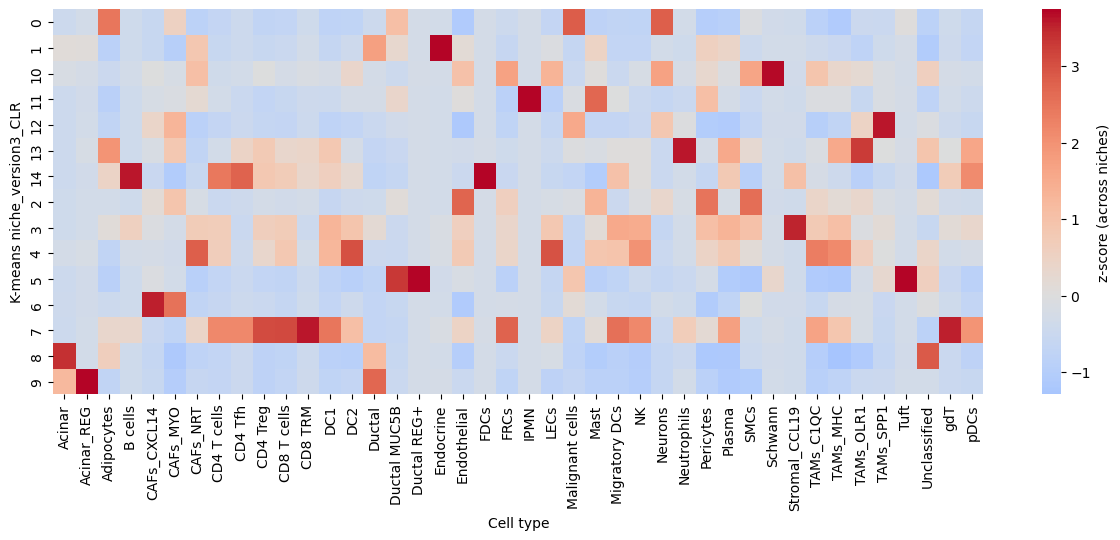

In [21]:
# z-score across niches per column -- manual
niche_means_z = (niche_means - niche_means.mean(axis=0)) / niche_means.std(axis=0, ddof=0)
plt.figure(figsize=(15, 5))
sns.heatmap(niche_means_z, cmap="coolwarm", center=0, cbar_kws={"label": "z-score (across niches)"})
plt.xlabel("Cell type"); plt.ylabel("K-means niche_version3_CLR")

In [23]:
# 1) Define your mapping from old → new
niche_name_map = {
    "0": "Tumour_DuctalMUC5B_MYO_enriched",
    "1": "Endocrine_Ductal_enriched",
    "10": "LymphoidStromal_Schwann_TAMs_C1QC_enriched",
    "11": "IPMN_DuctalMUC5B_Mast_enriched", 
    "12": "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched", 
    "13": "Plasma_Neutrophils_enriched",
    "14": "B_FDCs_CD4Tfh_enriched",
    "2": "Vasculature_enriched",
    "3": "B_Lymphoids_Stromal_CCL19_enriched",
    "4": "Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched", 
    "5": "Tumour_Tuft_DuctalMUC5B_enriched",
    "6": "Tumour_Myofibroblast_MYO_CXCL14_enriched",
    "7": "Lymphoid_MigratoryDCs_enriched",
    "8": "Acinar_Ductal_enriched",
    "9": "AcinarREG_enriched"
}

# 2) Map into a new obs column
combined.obs["global_niche_CLR"] = combined.obs["niche_CLR_km"].map(niche_name_map)

# 3) Verify
print(combined.obs[["global_niche_CLR","niche_CLR_km"]].drop_duplicates())

                                                   global_niche_CLR  \
aaaaalmd-1-MH096_480    Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched   
aaaaapma-1-MH074_480                         Acinar_Ductal_enriched   
aaaabaof-1-MH106_480                 IPMN_DuctalMUC5B_Mast_enriched   
aaaabcpb-1-MH099_314       Tumour_Myofibroblast_MYO_CXCL14_enriched   
aaaabhie-1-MH106_314                Tumour_DuctalMUC5B_MYO_enriched   
aaaacmmk-1-MH099_480                 Lymphoid_MigratoryDCs_enriched   
aaaadkln-1-MH097_314                             AcinarREG_enriched   
aaaaecbl-1-MH074_480                           Vasculature_enriched   
aaaafndf-1-MH104_314     LymphoidStromal_Schwann_TAMs_C1QC_enriched   
aaaaggdh-1-MH107_480                    Plasma_Neutrophils_enriched   
aaaaheob-1-MH099_314  Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched   
aaabnpeb-1-MH107_480                      Endocrine_Ductal_enriched   
aaadhhia-1-MH065_314             B_Lymphoids_Stromal_CCL19_enriched   
aabood

In [25]:
combined.obs["global_niche_CLR"].value_counts()

global_niche_CLR
AcinarREG_enriched                               353807
Tumour_DuctalMUC5B_MYO_enriched                  322415
Acinar_Ductal_enriched                           304150
Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched    302666
Vasculature_enriched                             282182
Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched      265597
Plasma_Neutrophils_enriched                      249119
Tumour_Myofibroblast_MYO_CXCL14_enriched         247286
Lymphoid_MigratoryDCs_enriched                   176448
Endocrine_Ductal_enriched                        150152
B_Lymphoids_Stromal_CCL19_enriched                88100
LymphoidStromal_Schwann_TAMs_C1QC_enriched        79650
B_FDCs_CD4Tfh_enriched                            46773
Tumour_Tuft_DuctalMUC5B_enriched                  39171
IPMN_DuctalMUC5B_Mast_enriched                    22725
Name: count, dtype: int64

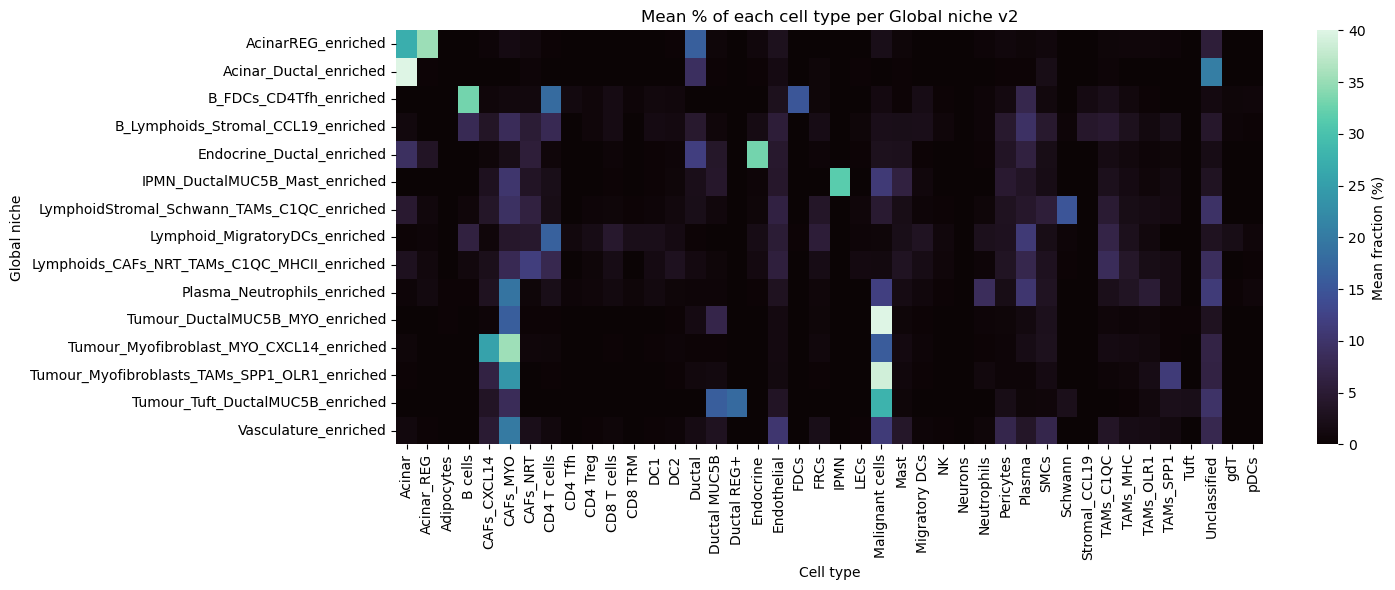

In [27]:
niche_means_names = (
    dfX.join(combined.obs["global_niche_CLR"])
       .groupby("global_niche_CLR")
       .mean()
       .sort_index()
)
# convert to percentage
niche_means_names_pct = niche_means_names * 100.0

# plot
plt.figure(figsize=(15, 6))
sns.heatmap(
    niche_means_names_pct,
    cmap="mako",
    vmax=40,  # adjust for your data
    cbar_kws={"label": "Mean fraction (%)"},
    linewidths=0
)
plt.xlabel("Cell type")
plt.ylabel("Global niche")
plt.title("Mean % of each cell type per Global niche v2")
plt.tight_layout()
plt.show()

In [28]:
niche_color_map_clr = {
    "Acinar_Ductal_enriched": "#C7EAE5",
    "AcinarREG_enriched": "#01665E",
    "Endocrine_Ductal_enriched": '#e377c2',
    "Tumour_Tuft_DuctalMUC5B_enriched": "#7A0177", #"#9467bd",
    "B_FDCs_CD4Tfh_enriched": "#FD8D3C" ,
    "B_Lymphoids_Stromal_CCL19_enriched":"#aec7e8",
    "Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched":'#c5b0d5',
    "Lymphoid_MigratoryDCs_enriched": "#08519C",
    "LymphoidStromal_Schwann_TAMs_C1QC_enriched": "#FCC5C0", #"#B3B3B3",
    "Plasma_Neutrophils_enriched": '#98df8a',
    "Vasculature_enriched": "#d62728",  
    "Tumour_Myofibroblast_MYO_CXCL14_enriched": "#DFC27D",
    "Tumour_DuctalMUC5B_MYO_enriched":"#8c564b",
    "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched": "#17becf",
     "IPMN_DuctalMUC5B_Mast_enriched":"#B3B3B3"
}

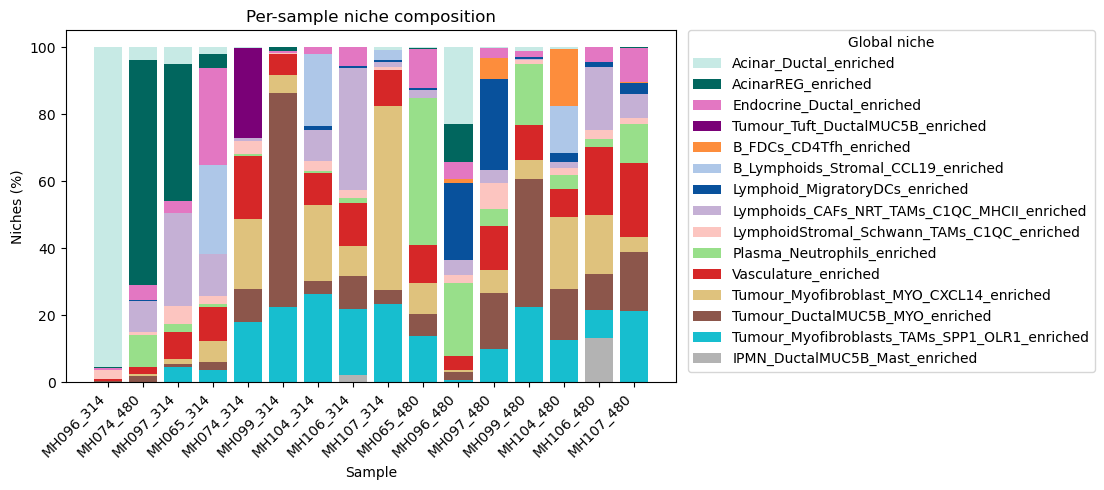

In [30]:
# make sure these exist
assert "sample" in combined.obs.columns
assert "global_niche_CLR" in combined.obs.columns

# count table: rows = samples, cols = niches
ct_counts = pd.crosstab(combined.obs["sample"], combined.obs["global_niche_CLR"])
ct_props  = ct_counts.div(ct_counts.sum(axis=1), axis=0) * 100  # row-wise %

niche_order =["Acinar_Ductal_enriched", "AcinarREG_enriched", "Endocrine_Ductal_enriched", 
               "Tumour_Tuft_DuctalMUC5B_enriched", 
              "B_FDCs_CD4Tfh_enriched","B_Lymphoids_Stromal_CCL19_enriched",
              "Lymphoid_MigratoryDCs_enriched","Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched",
              "LymphoidStromal_Schwann_TAMs_C1QC_enriched","Plasma_Neutrophils_enriched",
              "Vasculature_enriched",
              "Tumour_Myofibroblast_MYO_CXCL14_enriched","Tumour_DuctalMUC5B_MYO_enriched",
              "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched","IPMN_DuctalMUC5B_Mast_enriched"] 

sample_order = ["MH096_314","MH074_480","MH097_314","MH065_314",
                "MH074_314", "MH099_314", "MH104_314", "MH106_314", "MH107_314", 
                "MH065_480", "MH096_480", "MH097_480",
                "MH099_480", "MH104_480", "MH106_480", "MH107_480"]

# keep only those that exist; add any missing to the end (or drop)
niche_order = [n for n in niche_order if n in ct_props.columns] + \
              [n for n in ct_props.columns if n not in niche_order]

# reorder columns
ct_props = ct_props.reindex(columns=niche_order)

# Optional: define desired sample order
sample_order = [s for s in sample_order if s in ct_props.index]
ct_props = ct_props.loc[sample_order]

# consistent colors for niches
niches = ct_props.columns.astype(str)
palette = niche_color_map_clr

# stacked % bar chart (samples on x-axis)
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(ct_props)), 5))

top = np.full(len(ct_props), 100.0)  # start at 100%
x = np.arange(len(ct_props))

for niche in niches:
    vals = ct_props[niche].values
    ax.bar(
        x,
        vals,
        bottom=top - vals,     # position so that we build downward
        label=niche,
        linewidth=0,
        color=palette[niche],
        width=0.8
    )
    top -= vals  

ax.set_xticks(x)
ax.set_xticklabels(ct_props.index, rotation=45, ha="right")
ax.set_ylabel("Niches (%)")
ax.set_xlabel("Sample")
ax.set_title("Per-sample niche composition")
ax.legend(title="Global niche", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
#plt.savefig(f"figures/Niches_composition_CLR_Aug14_reorder.pdf",bbox_inches="tight")
fig.tight_layout()
plt.show()

In [12]:
from scipy.stats import zscore
niche_means_names_z = pd.DataFrame(
    zscore(niche_means_names.values, axis=0, nan_policy="omit"),
    index=niche_means_names.index,
    columns=niche_means_names.columns
)

Text(158.0815972222222, 0.5, 'K-means niche_version3_CLR')

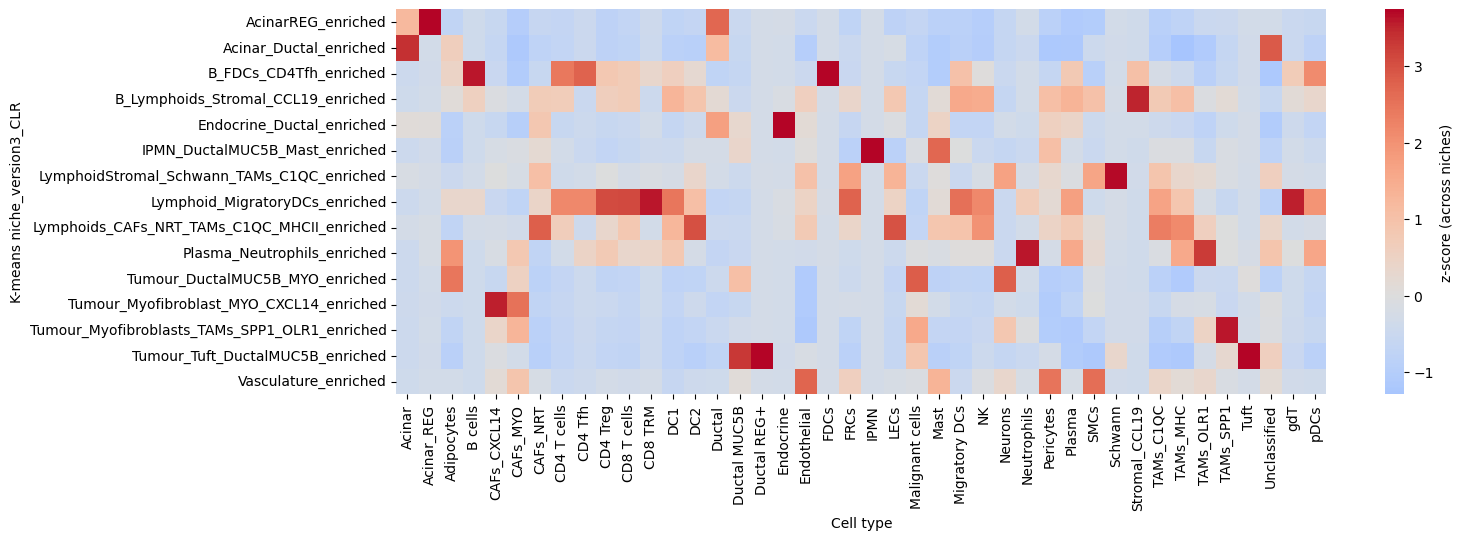

In [31]:
# z-score across niches per column -- manual
niche_means_name_z = (niche_means_names - niche_means_names.mean(axis=0)) / niche_means_names.std(axis=0, ddof=0)
plt.figure(figsize=(15, 5))
sns.heatmap(niche_means_name_z, cmap="coolwarm", center=0, cbar_kws={"label": "z-score (across niches)"})
plt.xlabel("Cell type"); plt.ylabel("K-means niche_version3_CLR")

<Figure size 1300x500 with 0 Axes>

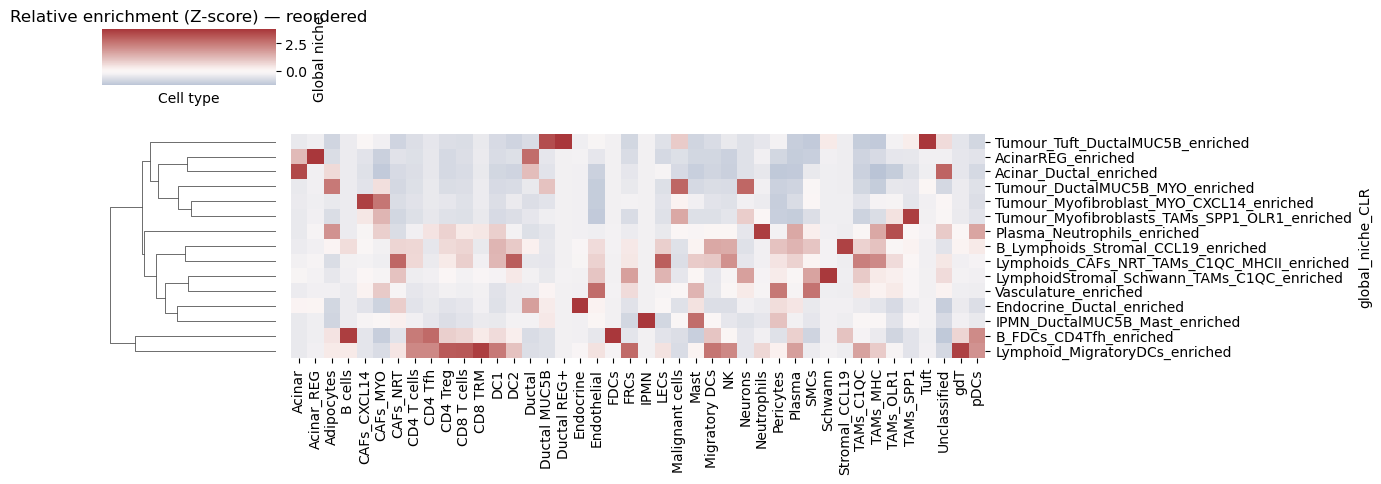

In [35]:
plt.figure(figsize=(13, 5))
sns.clustermap(
    niche_means_name_z,
    cmap="vlag",
    center=0,
    row_cluster=True, 
    col_cluster=False,
    #vmax=3,
    #vmin=-1.5,
    cbar_kws={"label": "z-score (across niches)"},
    linewidths=0,
    figsize=(13,5)
)
plt.xlabel("Cell type")
plt.ylabel("Global niche")
plt.title("Relative enrichment (Z-score) — reordered")
plt.tight_layout()
#plt.savefig(f"figures/Niches_composition_celltype.pdf",bbox_inches="tight")
plt.show()

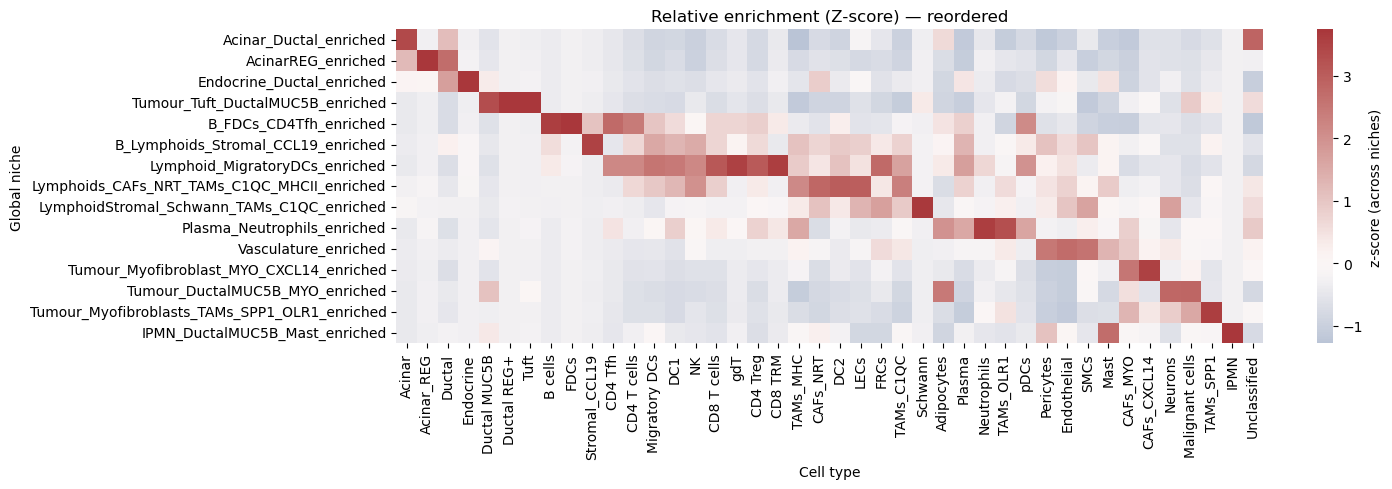

In [36]:
niche_order = ["Acinar_Ductal_enriched", "AcinarREG_enriched", "Endocrine_Ductal_enriched", 
               "Tumour_Tuft_DuctalMUC5B_enriched", 
              "B_FDCs_CD4Tfh_enriched","B_Lymphoids_Stromal_CCL19_enriched",
              "Lymphoid_MigratoryDCs_enriched","Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched",
              "LymphoidStromal_Schwann_TAMs_C1QC_enriched","Plasma_Neutrophils_enriched",
              "Vasculature_enriched",
              "Tumour_Myofibroblast_MYO_CXCL14_enriched","Tumour_DuctalMUC5B_MYO_enriched",
              "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched","IPMN_DuctalMUC5B_Mast_enriched"] 
niche_order = [n for n in niche_order if n in niche_means_name_z.index]


cell_type_order = ["Acinar","Acinar_REG","Ductal","Endocrine","Ductal MUC5B","Ductal REG+","Tuft",
                   "B cells", "FDCs", "Stromal_CCL19","CD4 Tfh",
                   "CD4 T cells",
                   "Migratory DCs","DC1","NK",
                   "CD8 T cells", "gdT",
                   "CD4 Treg","CD8 TRM","TAMs_MHC","CAFs_NRT","DC2","LECs","FRCs", "TAMs_C1QC",
                   "Schwann","Adipocytes","Plasma","Neutrophils","TAMs_OLR1","pDCs",
                   "Pericytes","Endothelial", "SMCs","Mast",
                   "CAFs_MYO","CAFs_CXCL14","Neurons","Malignant cells","TAMs_SPP1",
                   "IPMN","Unclassified"
                   
]
cell_type_order = [ct for ct in cell_type_order if ct in niche_means_name_z.columns]

# Reorder DataFrame
#niche_means_z_reordered = niche_means_z.loc[niche_order, niche_means_z.columns[col_order]]
niche_means_z_reordered = niche_means_name_z.loc[niche_order, cell_type_order]

plt.figure(figsize=(15, 5))
sns.heatmap(
    niche_means_z_reordered,
    cmap="vlag",
    center=0,
    #vmax=3,
    #vmin=-1.5,
    cbar_kws={"label": "z-score (across niches)"},
    linewidths=0
)
plt.xlabel("Cell type")
plt.ylabel("Global niche")
plt.title("Relative enrichment (Z-score) — reordered")
plt.tight_layout()
#plt.savefig(f"figures/Niches_composition_celltype.pdf",bbox_inches="tight")
plt.show()

In [95]:
combined

AnnData object with n_obs × n_vars = 2930241 × 42
    obs: 'sample', 'cell_id', 'niche_CLR_km', 'global_niche_CLR'
    obsm: 'spatial'

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

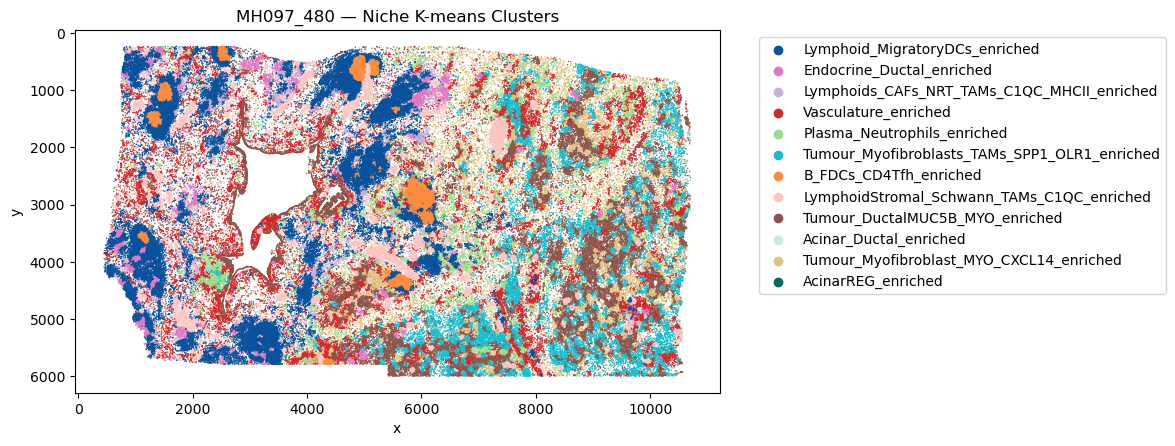

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sample = "MH097_480"  # pick your sample

# subset from combined
ad_one = combined[combined.obs["sample"] == sample].copy()

# make DataFrame for plotting
df_plot = ad_one.obs.copy()
df_plot[["x", "y"]] = ad_one.obsm["spatial"]

# plot with seaborn
plt.figure(figsize=(12, 12))
sns.scatterplot(
    data=df_plot,
    x="x", y="y",
    hue="global_niche_CLR",
    palette=niche_color_map_clr,
    s=1,
    rasterized=True,        # <— THIS is key
    linewidth=0
)
plt.gca().set_aspect("equal")   # keep aspect ratio
plt.gca().invert_yaxis()        # match image orientation if needed
plt.title(f"{sample} — Niche K-means Clusters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(f"figures/Representative_niches_097_480.pdf",dpi=300,bbox_inches="tight")
plt.show()

/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/homevol/huemail/miniconda3/envs/xenium.squidpy/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_d

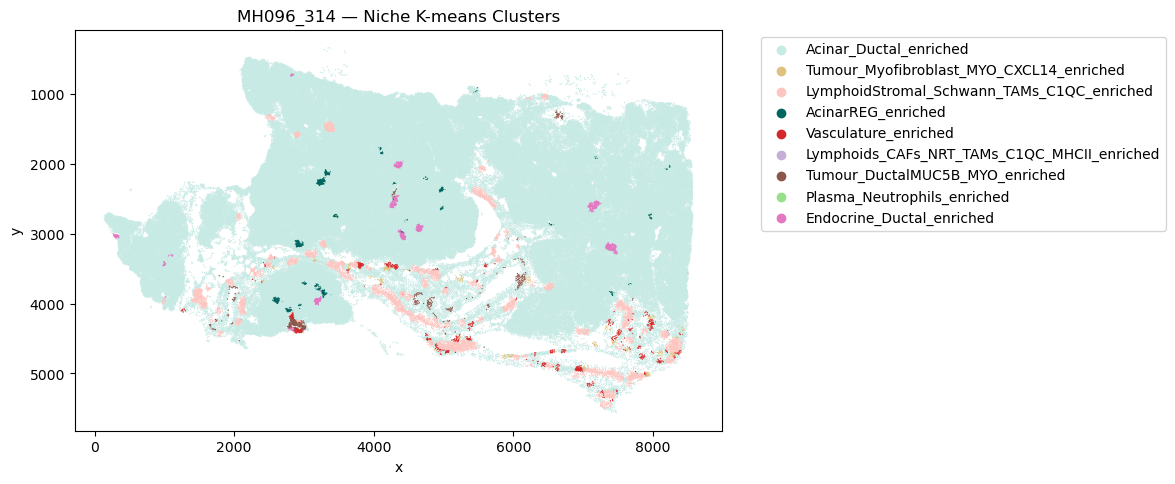

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sample = "MH096_314"  # pick your sample

# subset from combined
ad_one = combined[combined.obs["sample"] == sample].copy()

# make DataFrame for plotting
df_plot = ad_one.obs.copy()
df_plot[["x", "y"]] = ad_one.obsm["spatial"]

# plot with seaborn
plt.figure(figsize=(12, 12))
sns.scatterplot(
    data=df_plot,
    x="x", y="y",
    hue="global_niche_CLR",
    palette=niche_color_map_clr,
    s=1,
    rasterized=True,        # <— THIS is key
    linewidth=0
)
plt.gca().set_aspect("equal")   # keep aspect ratio
plt.gca().invert_yaxis()        # match image orientation if needed
plt.title(f"{sample} — Niche K-means Clusters")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig(f"figures/Representative_niches_097_480.pdf",dpi=300,bbox_inches="tight")
plt.show()

/tmp/ipykernel_178711/2753169745.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  filtered.groupby(["global_niche_CLR", "sample"])
/tmp/ipykernel_178711/2753169745.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap("tab20b", len(samples))


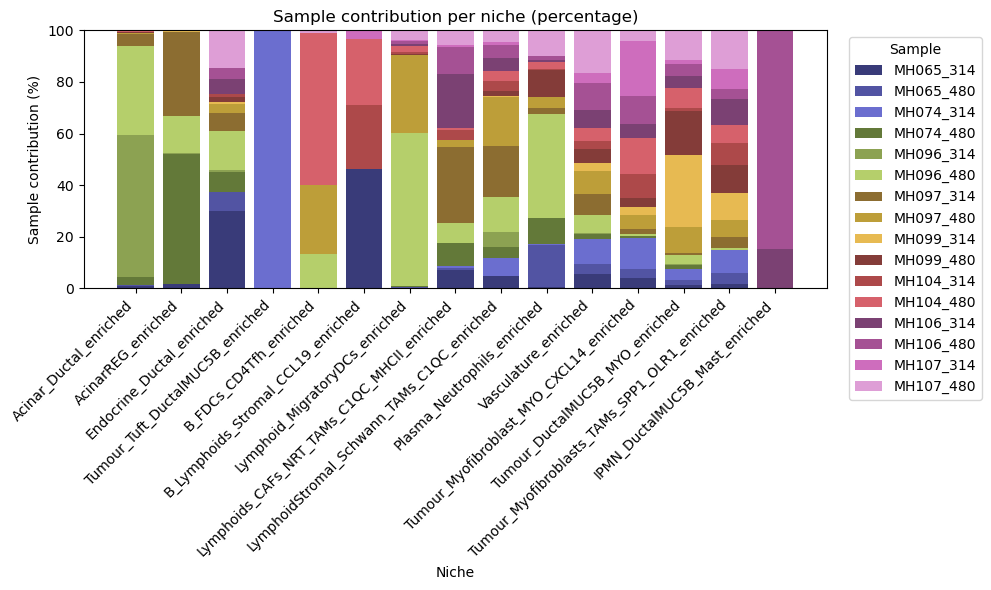

In [47]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.cm import get_cmap

niche_order = [
    "Acinar_Ductal_enriched", "AcinarREG_enriched", "Endocrine_Ductal_enriched", 
    "Tumour_Tuft_DuctalMUC5B_enriched", 
    "B_FDCs_CD4Tfh_enriched", "B_Lymphoids_Stromal_CCL19_enriched",
    "Lymphoid_MigratoryDCs_enriched", "Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched",
    "LymphoidStromal_Schwann_TAMs_C1QC_enriched", "Plasma_Neutrophils_enriched",
    "Vasculature_enriched",
    "Tumour_Myofibroblast_MYO_CXCL14_enriched", "Tumour_DuctalMUC5B_MYO_enriched",
    "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched", "IPMN_DuctalMUC5B_Mast_enriched"
]


# 1. Filter out unclassified cells
label_col = "global_niche_CLR"
filtered = combined.obs.loc[
    ~combined.obs[label_col].isin(["Unclassified", "Unassigned"])
]

# 2. Group by niche and sample to get counts
counts_by_niche_sample = (
    filtered.groupby(["global_niche_CLR", "sample"])
            .size()
            .unstack(fill_value=0)  # rows = niches, columns = samples
)

# 3. Convert to percentages (row-wise)
counts_pct = counts_by_niche_sample.div(counts_by_niche_sample.sum(axis=1), axis=0) * 100

# Filter and reorder to include only the niches in your desired order
counts_pct = counts_pct.loc[
    counts_pct.index.intersection(niche_order)  # keep only available ones
]

# Now reorder to match your desired order exactly
counts_pct = counts_pct.reindex(niche_order)

# Reorder sample columns
sample_order = ["MH065_314", "MH065_480","MH074_314", "MH074_480","MH096_314","MH096_480",
                "MH097_314","MH097_480","MH099_314", "MH099_480","MH104_314","MH104_480",
                "MH106_314", "MH106_480","MH107_314", "MH107_480"
]


# 4. Set up color map for samples using "Paired"
samples = [s for s in sample_order if s in counts_pct.columns]
cmap = get_cmap("tab20b", len(samples))
sample_colors = {sample: cmap(i % cmap.N) for i, sample in enumerate(samples)}

#counts_pct = counts_pct.loc[counts_pct.index.intersection(niche_order)]
#counts_pct = counts_pct.reindex(niche_order)  # enforce exact order

# 5. Plot stacked percentage bar
fig, ax = plt.subplots(figsize=(max(10, 0.6 * len(counts_pct)), 6))

bottom = np.zeros(len(counts_pct))
x = np.arange(len(counts_pct))
niches = counts_pct.index

for sample in samples:
    vals = counts_pct[sample].values
    ax.bar(
        x, vals, bottom=bottom,
        label=sample,
        color=sample_colors[sample],
        width=0.8
    )
    bottom += vals

# Labeling
ax.set_xticks(x)
ax.set_xticklabels(niches, rotation=45, ha="right")
ax.set_ylabel("Sample contribution (%)")
ax.set_xlabel("Niche")
ax.set_title("Sample contribution per niche (percentage)")
ax.set_ylim(0, 100)
ax.legend(title="Sample", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
#plt.savefig("figures/Samplecontributionperniche.pdf")
plt.show()

/tmp/ipykernel_178711/3740765624.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby(["sample", label_col])


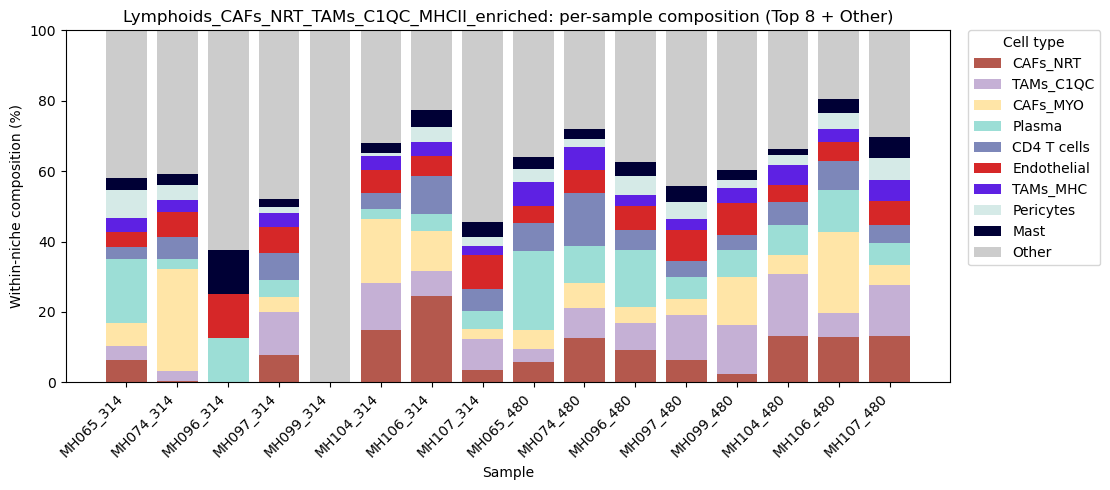

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

niche = "Lymphoids_CAFs_NRT_TAMs_C1QC_MHCII_enriched" #,"LymphoidStromal_Schwann_TAMs_C1QC_enriched", "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched"]
label_col = "cell_type"

# 1) Subset to niche and exclude unwanted labels
subset = combined.obs.loc[
    (combined.obs["global_niche_CLR"] == niche)
    & (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
].copy()

if subset.empty:
    raise ValueError(f"No cells found in niche '{niche}' after exclusions.")

# 2) Top 8 contributors overall (within this niche)
top8 = subset[label_col].value_counts().head(9).index.tolist()

# 3) Per-sample counts pivot (samples x cell types)
counts = (
    subset.groupby(["sample", label_col])
          .size()
          .unstack(fill_value=0)
)

# ensure all top8 columns exist even if some samples miss them
for ct in top8:
    if ct not in counts.columns:
        counts[ct] = 0

# 4) Row-wise % and collapse others into "Other"
row_totals = counts.sum(axis=1).replace(0, np.nan)
perc = counts.div(row_totals, axis=0) * 100

perc_top8 = perc[top8]                      # keep only top 8
perc_other = 100 - perc_top8.sum(axis=1)    # collapse rest
plot_df = perc_top8.copy()
plot_df["Other"] = perc_other.clip(lower=0) # numeric safety
plot_df = plot_df.fillna(0)

manual_colors = {
    'Acinar': '#ffb500',
    'Acinar_REG':'#17becf',
    'Adipocytes': 'black',
    'B cells':  '#ff7f0e',
    'CAFs_CXCL14':'#FFB0A7',
    'CAFs_MYO': '#FFE5A7', #'#c7c7c7',
    'CAFs_NRT': "#B4584D",
    "CD4 T cells":  '#7d87b9',
    "CD4 Tfh" : "#46487E",
    "CD4 Treg": '#536CC7',
    "CD8 T cells":'#023fa5',
    "CD8 TRM": "#0A295E",
    "DC1": "#888D07",
    "DC2": "#717417", 
    "Ductal": '#00846f',
    "Ductal MUC5B":'#8dd593',
    "Endocrine": '#809693',
    "Endothelial":'#d62728',
    "FDCs":"#DD51AD",
    "FRCs": "#00BFA0",
    "LECs": "#535A06",
    "Malignant cells": '#8c564b',
    "Mast": '#000035',
    "Migratory DCs": "#105354",
    "NK": "#00025E",
    "Neutrophils": '#b903aa',
    "Pericytes": '#d5eae7', #'#c5b0d5',
    "Plasma": '#9cded6',
    "SMCs": '#d5eae7', #'#c5b0d5',
    "Schwann": '#b79762',
    "TAMs_C1QC":'#c5b0d5',
    "TAMs_MHC": "#5E21E3",
    "TAMs_OLR1":'#e377c2',
    "TAMs_SPP1": '#17becf',
    "Unclassified": "#cccccc",
    "gdT": '#000035', 
    "pDCs":'#1b4400',
    "Tuft": '#9467bd',
    "Other": "#cccccc"
}

# 5) Plot stacked bar per sample
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(plot_df)), 5))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df))
cols = top8 + ["Other"]

# optional: reuse your manual color map; fallback to grey for "Other"
try:
    color_map = manual_colors.copy()
except NameError:
    color_map = {}
color_map.setdefault("Other", "#cccccc")

for col in cols:
    vals = plot_df[col].values
    ax.bar(
        x, vals, bottom=bottom,
        label=col,
        color=color_map.get(col, "#cccccc"),
        width=0.8, linewidth=0
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str), rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Within-niche composition (%)")
ax.set_xlabel("Sample")
ax.set_title(f"{niche}: per-sample composition (Top 8 + Other)")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
fig.tight_layout()
#plt.savefig("figures/LymphoidNRTC1QC_niche_acrossPatients.pdf", dpi=300)
plt.show()


/tmp/ipykernel_178711/1752038267.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby(["sample", label_col])


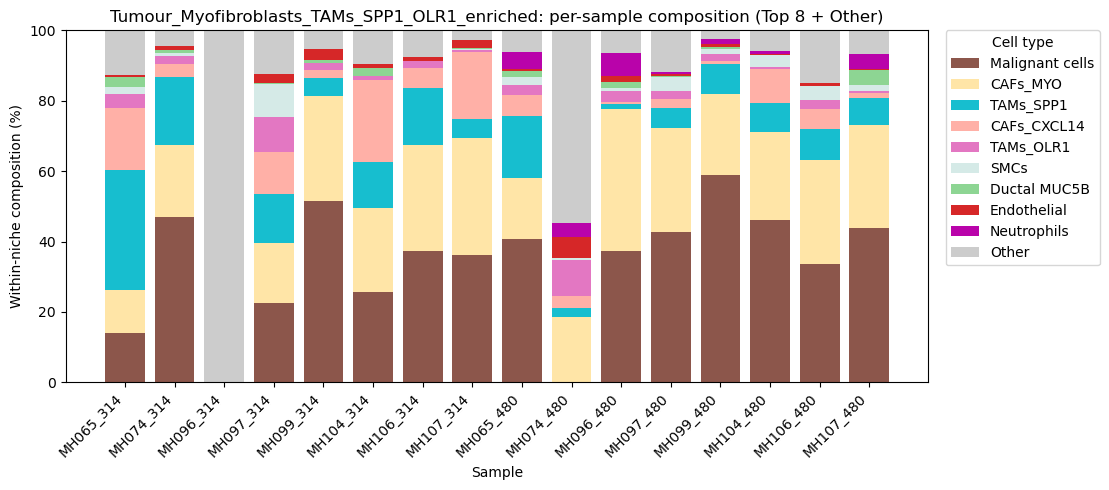

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

niche = "Tumour_Myofibroblasts_TAMs_SPP1_OLR1_enriched" #,"LymphoidStromal_Schwann_TAMs_C1QC_enriched", ""]
label_col = "cell_type"

# 1) Subset to niche and exclude unwanted labels
subset = combined.obs.loc[
    (combined.obs["global_niche_CLR"] == niche)
    & (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
].copy()

if subset.empty:
    raise ValueError(f"No cells found in niche '{niche}' after exclusions.")

# 2) Top 8 contributors overall (within this niche)
top8 = subset[label_col].value_counts().head(9).index.tolist()

# 3) Per-sample counts pivot (samples x cell types)
counts = (
    subset.groupby(["sample", label_col])
          .size()
          .unstack(fill_value=0)
)

# ensure all top8 columns exist even if some samples miss them
for ct in top8:
    if ct not in counts.columns:
        counts[ct] = 0

# 4) Row-wise % and collapse others into "Other"
row_totals = counts.sum(axis=1).replace(0, np.nan)
perc = counts.div(row_totals, axis=0) * 100

perc_top8 = perc[top8]                      # keep only top 8
perc_other = 100 - perc_top8.sum(axis=1)    # collapse rest
plot_df = perc_top8.copy()
plot_df["Other"] = perc_other.clip(lower=0) # numeric safety
plot_df = plot_df.fillna(0)


# 5) Plot stacked bar per sample
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(plot_df)), 5))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df))
cols = top8 + ["Other"]

# optional: reuse your manual color map; fallback to grey for "Other"
try:
    color_map = manual_colors.copy()
except NameError:
    color_map = {}
color_map.setdefault("Other", "#cccccc")

for col in cols:
    vals = plot_df[col].values
    ax.bar(
        x, vals, bottom=bottom,
        label=col,
        color=color_map.get(col, "#cccccc"),
        width=0.8, linewidth=0
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str), rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Within-niche composition (%)")
ax.set_xlabel("Sample")
ax.set_title(f"{niche}: per-sample composition (Top 8 + Other)")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
fig.tight_layout()
#plt.savefig("figures/LymphoidNRTC1QC_niche_acrossPatients.pdf", dpi=300)
plt.show()


/tmp/ipykernel_178711/2852428250.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  subset.groupby(["sample", label_col])


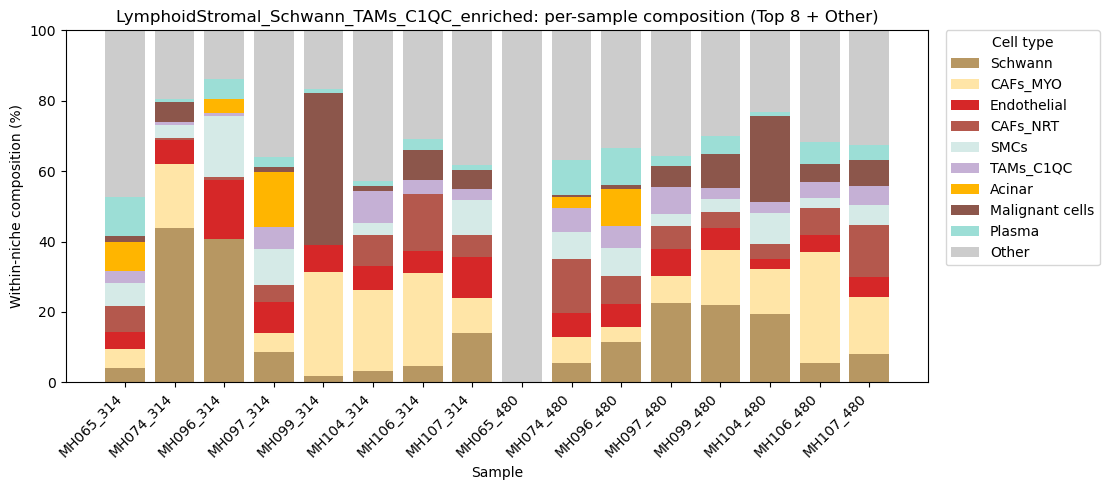

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

niche = "LymphoidStromal_Schwann_TAMs_C1QC_enriched" 
label_col = "cell_type"

# 1) Subset to niche and exclude unwanted labels
subset = combined.obs.loc[
    (combined.obs["global_niche_CLR"] == niche)
    & (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
].copy()

if subset.empty:
    raise ValueError(f"No cells found in niche '{niche}' after exclusions.")

# 2) Top 8 contributors overall (within this niche)
top8 = subset[label_col].value_counts().head(9).index.tolist()

# 3) Per-sample counts pivot (samples x cell types)
counts = (
    subset.groupby(["sample", label_col])
          .size()
          .unstack(fill_value=0)
)

# ensure all top8 columns exist even if some samples miss them
for ct in top8:
    if ct not in counts.columns:
        counts[ct] = 0

# 4) Row-wise % and collapse others into "Other"
row_totals = counts.sum(axis=1).replace(0, np.nan)
perc = counts.div(row_totals, axis=0) * 100

perc_top8 = perc[top8]                      # keep only top 8
perc_other = 100 - perc_top8.sum(axis=1)    # collapse rest
plot_df = perc_top8.copy()
plot_df["Other"] = perc_other.clip(lower=0) # numeric safety
plot_df = plot_df.fillna(0)


# 5) Plot stacked bar per sample
fig, ax = plt.subplots(figsize=(max(10, 0.7*len(plot_df)), 5))

bottom = np.zeros(len(plot_df))
x = np.arange(len(plot_df))
cols = top8 + ["Other"]

# optional: reuse your manual color map; fallback to grey for "Other"
try:
    color_map = manual_colors.copy()
except NameError:
    color_map = {}
color_map.setdefault("Other", "#cccccc")

for col in cols:
    vals = plot_df[col].values
    ax.bar(
        x, vals, bottom=bottom,
        label=col,
        color=color_map.get(col, "#cccccc"),
        width=0.8, linewidth=0
    )
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index.astype(str), rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.set_ylabel("Within-niche composition (%)")
ax.set_xlabel("Sample")
ax.set_title(f"{niche}: per-sample composition (Top 8 + Other)")
ax.legend(title="Cell type", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)
fig.tight_layout()
#plt.savefig("figures/LymphoidNRTC1QC_niche_acrossPatients.pdf", dpi=300)
plt.show()


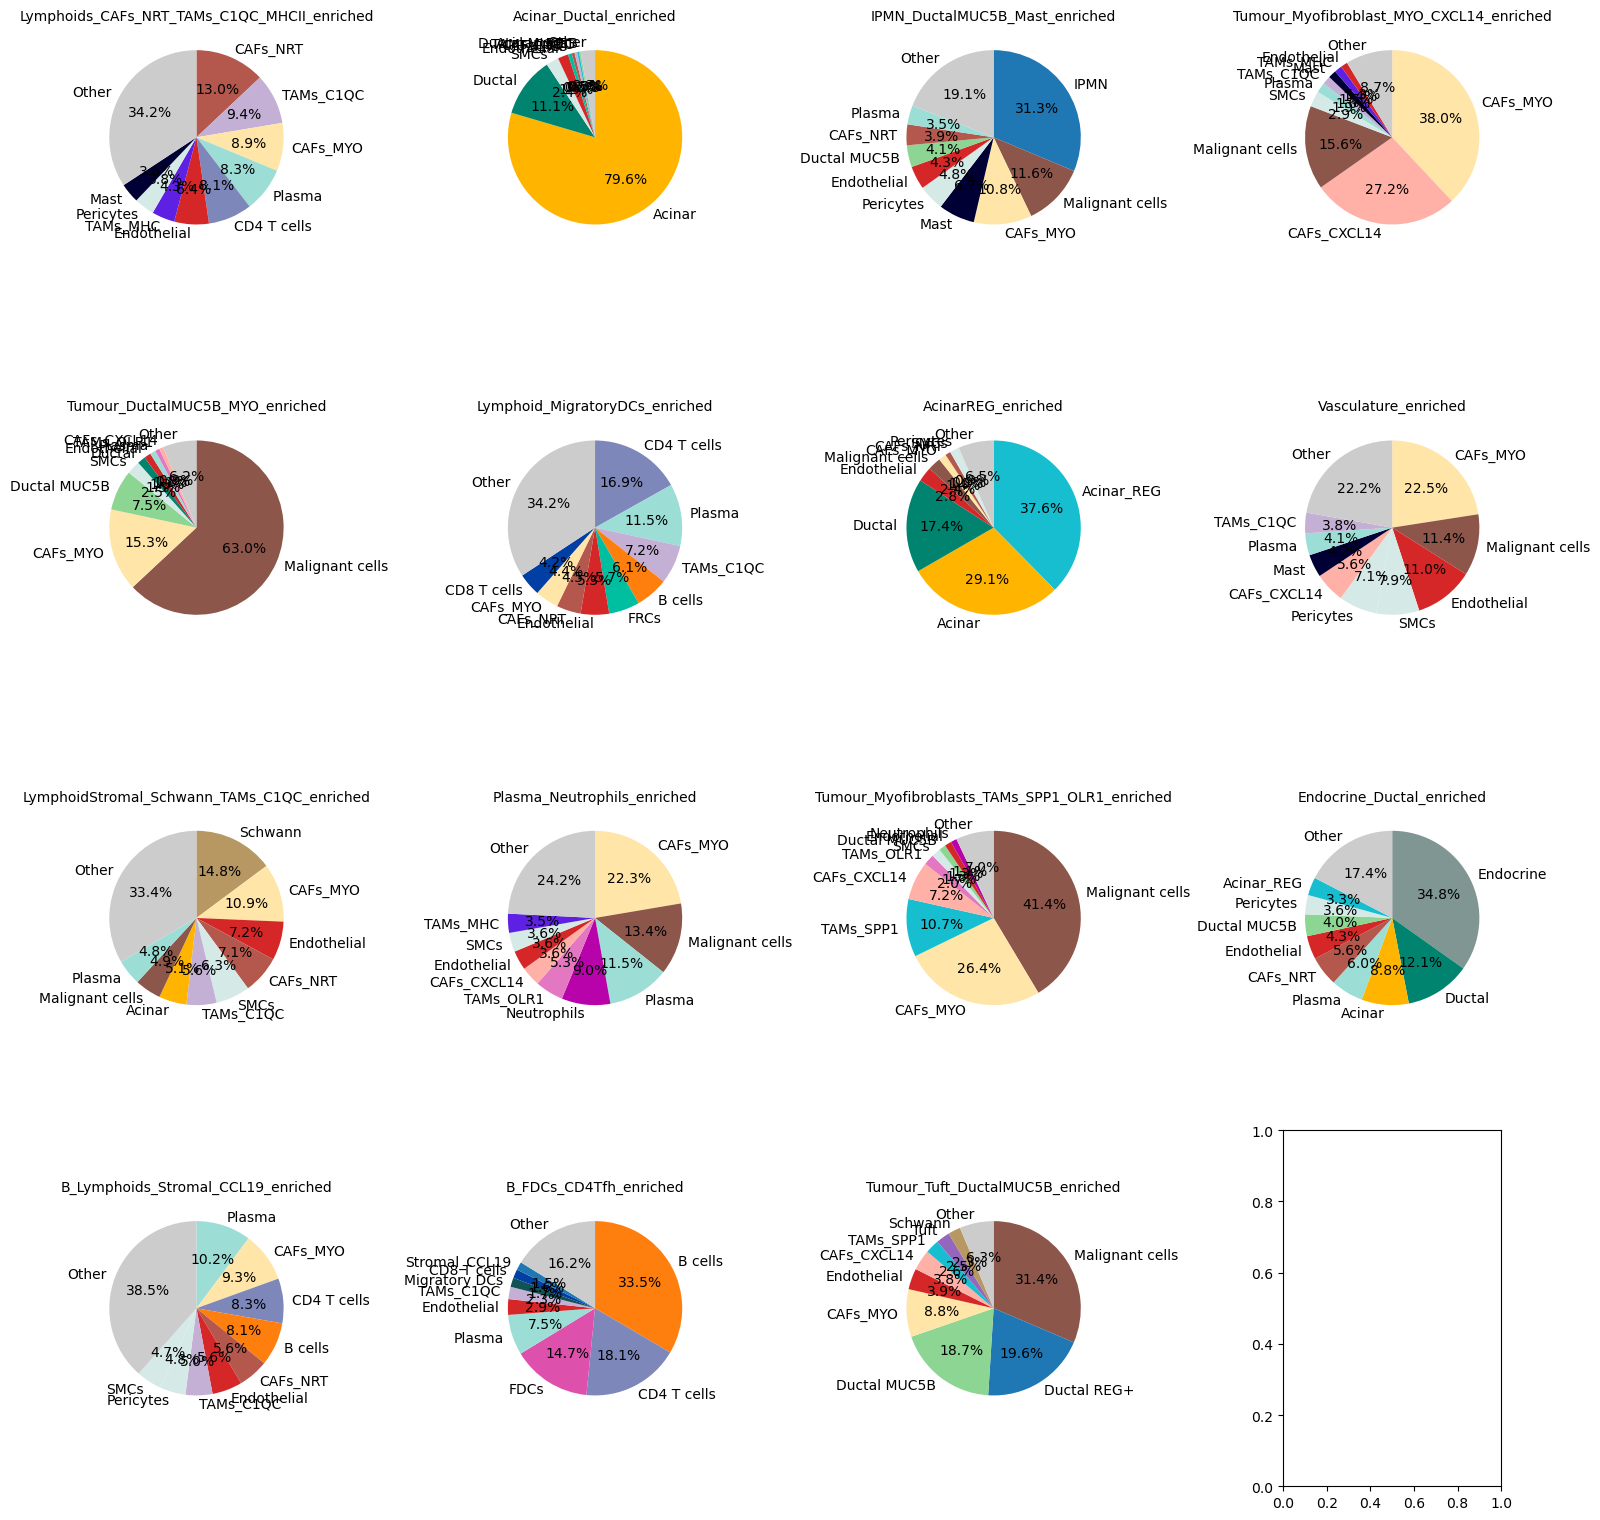

In [56]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_col = "cell_type"
all_niches = combined.obs["global_niche_CLR"].unique()
top_n = 9

# Prepare grid layout
n = len(all_niches)
cols = 4
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
axes = axes.flatten()

for i, niche in enumerate(all_niches):
    ax = axes[i]

    # 1. Filter data
    subset = combined.obs.loc[
        (combined.obs["global_niche_CLR"] == niche) &
        (~combined.obs[label_col].isin(["Unclassified", "Unassigned"]))
    ].copy()

    if subset.empty:
        ax.axis("off")
        continue

    # 2. Compute proportions
    pct = (subset[label_col].value_counts(normalize=True) * 100).sort_values(ascending=False)

    top = pct.head(top_n)
    other = pct.iloc[top_n:].sum()
    if other > 0:
        top = pd.concat([top, pd.Series({"Other": other})])

    # 3. Color mapping
    try:
        color_map = manual_colors.copy()
    except NameError:
        color_map = {}

    colors = []
    for ct in top.index:
        if ct == "Other":
            colors.append("#cccccc")
        else:
            colors.append(color_map.get(ct, None))

    # Assign fallback colors
    missing_idx = [i for i, c in enumerate(colors) if c is None]
    if missing_idx:
        pal = sns.color_palette("tab10", n_colors=len(missing_idx))
        for i_missing, p in zip(missing_idx, pal):
            colors[i_missing] = p

    # 4. Plot
    ax.pie(
        top.values,
        labels=top.index,
        autopct="%1.1f%%",
        startangle=90,
        counterclock=False,
        colors=colors
    )
    ax.set_title(niche, fontsize=10)

plt.tight_layout()
plt.show()
